In [26]:
import torch
import numpy as np
import torch.nn as nn
from tqdm import trange
from pathlib import Path
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from torchinfo import summary
import time
import sys
import pandas as pd
import scipy

import seaborn as sns
import sklearn.gaussian_process as gp
from scipy import stats

sys.path.append('../..')
sys.path.append('../../..')
sys.path.append('..')

sys.path.append('../nodes_2')

import plot_settings
plot_settings.apply()
COLORS = plot_settings.colors()
import importlib
#import multi_exp_log
import Param_symbol

import ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 as _lib

from IPython.display import display, Math


def import_reload():
    #importlib.reload(multi_exp_log)
    importlib.reload(Param_symbol)
from ecmm_vnode_vstatic_snode_sstatic_batch_lib_6 import *
import_reload()

In [27]:
RUN_ID = '1205_cook'
DT = 1
Q0 = 17921.57581 
SAVE  = True
ITS = int(1e4)

REF_VALUES = {
    'R0': 0.01,
    'R1': 0.01,
    'C1': 1000,
    'k':  0.01,
    's':  0.001,
    'sdot': 0.001
    }


VARIABLES = ['R0', 'R1', 'C1','k','s']
UNITS = {
    'R0': 'Ohm',
    'R1': 'Ohm',
    'C1': 'F',
    'k':  'GN/mm',
    's':  'um'
    }
N_VAR = len(VARIABLES)

SELECTION = "best"

In [28]:
model_name = '0510_2034_b4_combo_full_combo_V-dynamic_F-dynamic_642.62min_16h_2500eps.pt'
BAT_MODEL, ckpt = load_nn_model(model_name)

df = Param_symbol.read_raw_data('merged_DC_hyper')
trajs = prepare_data(df)
data = data_param(BAT_MODEL, trajs)
display(data)

Loaded checkpoint with config: {'R1_mode': 'net', 'C1_mode': 'net', 'R0_mode': 'net', 'n_hidden': 16, 'R1_constrained': 'false', 'R1_min': 0.005, 'R1_max': 0.25, 'C1_constrained': 'true', 'C1_min': 500.0, 'C1_max': 30000.0, 'R0_constrained': 'true', 'R0_min': 0.007, 'R0_max': 0.015, 'k_constrained': 'true', 'k_min': 0.02, 'k_max': 0.04, 's_constrained': 'true', 's_min': 0.0, 's_max': 0.5, 'sdot_constrained': 'true', 'sdot_min': 0.0, 'sdot_max': 0.001, 'style_V': 'dynamic', 'style_F': 'dynamic'}
Using I_ref = 24.89107751102174 and 'u_ref' = 4.297601866251944 for model parameters
k constrained to [0.02, 0.04] GN/1e-5m
ds/dt constrained to [0.0, 0.001] 1e-5 m / s  (dynamic sdotNet)
R1 unconstrained
C1 constrained to [500.0, 30000.0] F
R0 constrained to [0.007, 0.015] Ohm


,trajectory,C,u_per,I,u,soc,R1,C1,R0,k,s,sdot
0,0,0.56,26.5,2.787801,-3.808911,1.000000,0.009707,1785.063477,0.007000,0.032111,0.000000,0.000042
1,0,0.56,26.5,2.787801,-3.808911,0.999844,0.009707,1785.366211,0.007000,0.032111,0.000042,0.000042
2,0,0.56,26.5,2.787801,-3.808911,0.999689,0.009707,1785.670776,0.007000,0.032111,0.000084,0.000042
3,0,0.56,26.5,2.787801,-3.808911,0.999533,0.009707,1785.975342,0.007000,0.032112,0.000127,0.000042
4,0,0.56,26.5,2.787801,-3.808911,0.999378,0.009707,1786.280151,0.007000,0.032112,0.000169,0.000042
...,...,...,...,...,...,...,...,...,...,...,...,...
209564,124,5.00,0.0,24.891078,0.000000,0.233333,0.192620,4690.878418,0.009318,0.023301,0.291108,0.000541
209565,124,5.00,0.0,24.891078,0.000000,0.231944,0.192629,4627.829590,0.009670,0.023302,0.291649,0.000541
209566,124,5.00,0.0,24.891078,0.000000,0.230556,0.192637,4564.943359,0.010054,0.023303,0.292190,0.000541
209567,124,5.00,0.0,24.891078,0.000000,0.229167,0.192645,4502.242188,0.010466,0.023304,0.292731,0.000541


In [29]:
# import scipy.integrate as integrate
# from scipy.interpolate import interp1d

# def u_par_to_d(u_par):
#     d = L * u_par /100
#     return d

# def ds_dt(y,t,i,d,sNN_model = BAT_MODEL):
#     I_interp = interp1d(t, i, fill_value="extrapolate")
#     i = I_interp(t)
#     s, soc = y
#     soc_dot = -i / Q0
#     s_dot = sNN_model.ds_net(s,i, soc,d).detach().numpy()
#     y_dot = [s_dot, soc_dot]
#     return y_dot

# sol = 

# Importing data

In [30]:
N_TRAJS = len(data['trajectory'].unique())
print(f'Number of trajectories: {N_TRAJS}')

Number of trajectories: 125


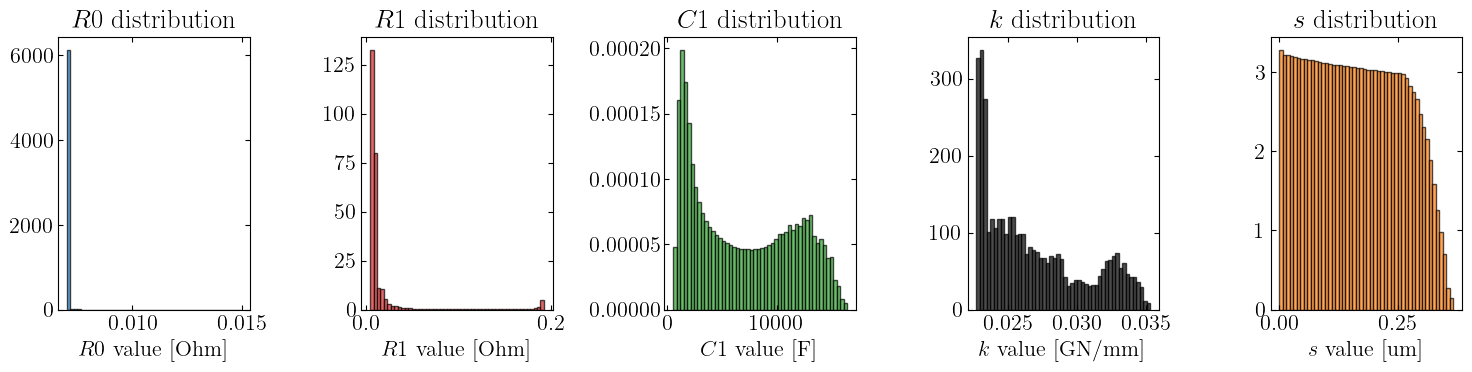

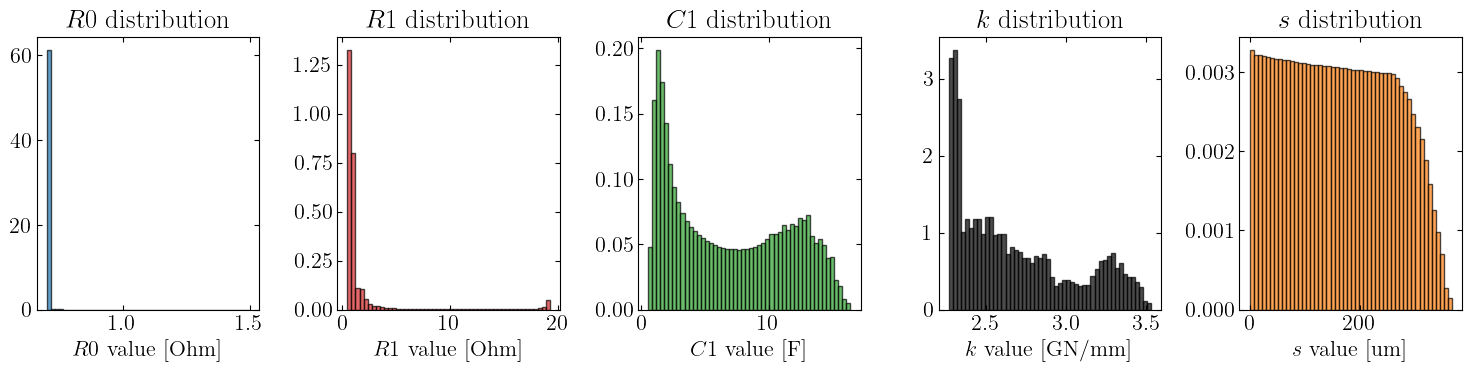

In [31]:
f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

f,ax = plt.subplots(1,N_VAR, figsize=(3*N_VAR,N_VAR*4/5))

for i, var in enumerate(VARIABLES):
    ax[i].hist(data[var] / REF_VALUES[var], bins=50, color=COLORS[i], alpha=0.7,edgecolor='black', density=True)
    ax[i].set_title(f'${var}$ distribution')
    ax[i].set_xlabel(f'${var}$ value [{UNITS[var]}]')
plt.tight_layout()
plt.show()

In [32]:
def get_XY(d_frame):
    for i in range(1,10):
        inds = np.arange(0,len(d_frame)) % i == 0
        if inds.sum() < 5e4:
            break

    X = d_frame[['C', 'u_per', 'soc']].values
    Y_R0 = d_frame['R0'].values / REF_VALUES['R0']
    Y_R1 = d_frame['R1'].values / REF_VALUES['R1']
    Y_C1 = d_frame['C1'].values / REF_VALUES['C1']
    Y_k  = d_frame['k'].values  / REF_VALUES['k']
    try:
        Y_s = d_frame['sdot'].values  / REF_VALUES['s']
        X_s = d_frame[['C', 'u_per', 'soc', 's']].values
        X_s[:,-1]/= REF_VALUES['s']
    except KeyError:
        print('No s column found, using reference value for all samples')
        Y_s = np.ones_like(Y_k) * REF_VALUES['s']
        X_s = np.ones_like(X)

    print(f'Using every {i}th data point for symbolic regression, total points: {inds.sum()}')
    
    return X[inds],Y_R0[inds], Y_R1[inds], Y_C1[inds], Y_k[inds], Y_s[inds], X_s[inds]

In [33]:
split_train = int(data['trajectory'].max() * 0.8)

# randomize trajectories before splitting into train and test sets

randomize = False
if randomize:
    data_rand = data.copy()
    data_rand['trajectory'] = np.random.permutation(data_rand['trajectory'].values)
    data_train  = data_rand[data_rand['trajectory'] <= split_train]
    data_test   = data_rand[data_rand['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)
else:

    data_train  = data[data['trajectory'] <= split_train]
    data_test   = data[data['trajectory'] > split_train]
    trajs_train = Param_symbol.prepare_data(data_train)
    trajs_test  = Param_symbol.prepare_data(data_test)

X_train, YR0_train, YR1_train, YC_train, Yk_train, Ys_train, Xs_train = get_XY(data_train)

X_test, YR0_test, YR1_test, YC_test, Yk_test, Ys_test, Xs_test = get_XY(data_test)

Y_train_dict = {
    'R0': YR0_train,
    'R1': YR1_train,
    'C1': YC_train,
    'k':  Yk_train,
    's':  Ys_train
}
Y_test_dict = {
    'R0': YR0_test,
    'R1': YR1_test,
    'C1': YC_test,
    'k':  Yk_test,
    's':  Ys_test
}

# u_C_pairs_train = data_train.loc[data_train['t'] == 0, ['u_par', 'C','trajectory']]
# u_C_pairs_test = data_test.loc[data_test['t'] == 0, ['u_par', 'C','trajectory']]


# plt.scatter(u_C_pairs_train['C'], u_C_pairs_train['u_par'],c= colors[0], label='Train')
# plt.scatter(u_C_pairs_test['C'], u_C_pairs_test['u_par'],  c= colors[1], label='Test')
# plt.xlabel('C-rate [a.u.]')
# plt.ylabel(r'$\Delta u / L_{tot}$ [a.u.]')
# plt.vlines(0.5,0,30, color='gray', linestyle='--')
# plt.vlines(5,0,30, color='gray', linestyle='--')
# plt.hlines(0,0.5,5, color='gray', linestyle='--')
# plt.hlines(30,0.5,5, color='gray', linestyle='--')
# plt.fill_between([0.5, 5], 0, 30, color='tab:blue', alpha=0.1)
# plt.legend(ncol = 2,loc='upper center', bbox_to_anchor=(0.5, 1.15))


Using every 4th data point for symbolic regression, total points: 48455
Using every 1th data point for symbolic regression, total points: 15749


# $R_0 = f_{R_0}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.0039349706
Equation: 0.7075021

Model 1: Complexity=5, Loss=0.0031542429
Equation: (0.008584766 / x2) + 0.68200666

Model 2: Complexity=7, Loss=0.0029277017
Equation: (0.00044620436 / square(x2)) + 0.6988391

Model 3: Complexity=9, Loss=0.0017672395
Equation: cube((x0 * 0.032343328) / x2) + 0.6918678

Model 4: Complexity=11, Loss=0.00049298763
Equation: cube(cube((x0 / x2) * 0.04365317)) + 0.6988973

Model 5: Complexity=13, Loss=0.00046859818
Equation: square(cube(((x0 / x2) * 0.06369303) + -0.45800522)) + 0.69811314

Model 6: Complexity=15, Loss=0.0004317224
Equation: sqrt(cube(cube((x0 / x2) * 0.050391264) + -0.22549361) + 0.5003863)

Model 7: Complexity=16, Loss=0.000414035
Equation: log(cube(cube(((x0 / x2) * 0.06473714) + -0.33497283)) + 2.0128143)

Model 8: Complexity=17, Loss=0.00034709065
Equation: cube(square(sin(cube((x0 * 0.049319677) / x2)))) + 0.69969344

Model 9: Complexity=18, Loss=0.0003110423
Equation: log(square(cube((x0 * (0.048480228 / 

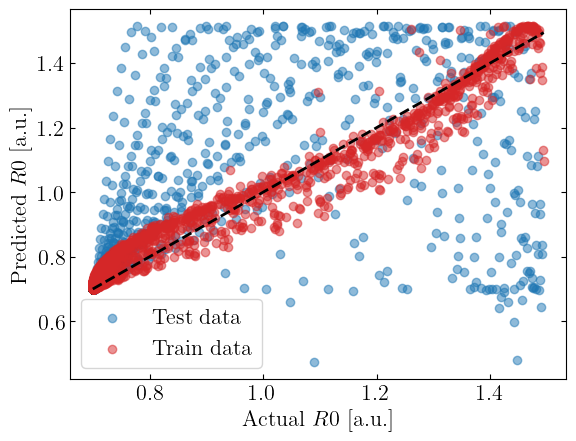

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (sin((-0.10491121*(x0/(x2 - 2.3637102) - 0.028776662)/x2)**(3*x0)) - 0.06604156)**3 + 0.6997219
Loss: 0.00010123325
Best model complexity: 27


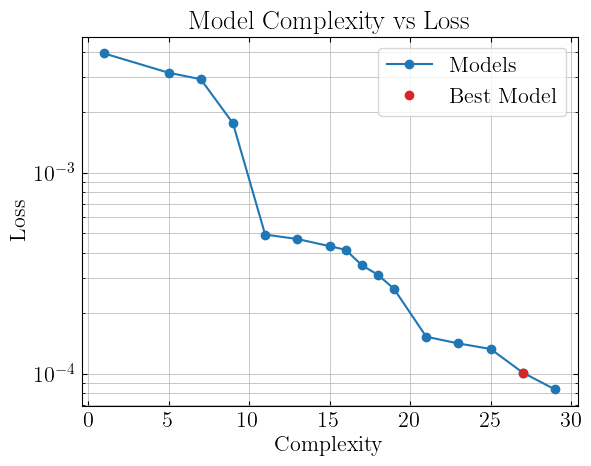

In [34]:
import_reload()
model_R0 = Param_symbol.run_symbolic_regression(X_train, YR0_train, model = None,run_id = f'R0_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R0 = model_R0.equations_
Param_symbol.print_models(df_model_R0)
import_reload() 
Param_symbol.parity_plot('R0',model_R0, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')
Param_symbol.print_best_model(model_R0)
Param_symbol.pareto_plot(model_R0)

# $R_1 = f_{R_1}(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=10.800158
Equation: 1.7108891

Model 1: Complexity=3, Loss=6.288519
Equation: 0.61789495 / x2

Model 2: Complexity=5, Loss=4.6024075
Equation: x0 * (0.49450424 / x2)

Model 3: Complexity=7, Loss=1.4689461
Equation: cube((x0 * 0.13413581) / x2)

Model 4: Complexity=9, Loss=1.0682645
Equation: cube(x0 * (0.13138235 / x2)) + 0.6672559

Model 5: Complexity=11, Loss=0.9872318
Equation: square(((x0 * -0.26711363) / x2) - -1.090484) + 0.46094477

Model 6: Complexity=12, Loss=0.9201416
Equation: 0.118975334 / (exp((x0 / x2) * -0.32258272) + 0.0046356735)

Model 7: Complexity=13, Loss=0.5225174
Equation: 3.3826408 / (cube(((x0 / x2) * -0.103320405) - -2.1228056) + 0.17443831)

Model 8: Complexity=14, Loss=0.3952044
Equation: 0.80000913 / (exp(cube((x0 / x2) * -0.0975519)) + 0.040826876)

Model 9: Complexity=15, Loss=0.3550123
Equation: 3.2551033 / ((x0 * cube(((x0 / x2) * -0.09384699) - -1.8469656)) + 0.17708243)

Model 10: Complexity=16, Loss=0.32919478
Equation: 0.

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: 0.82788926 + 0.96921706/(x2*exp(x0*(x0*(-0.36645705)/x2 - 1*(-5.1681623))) + 0.05142026)
Loss: 0.15408517
Best model complexity: 20


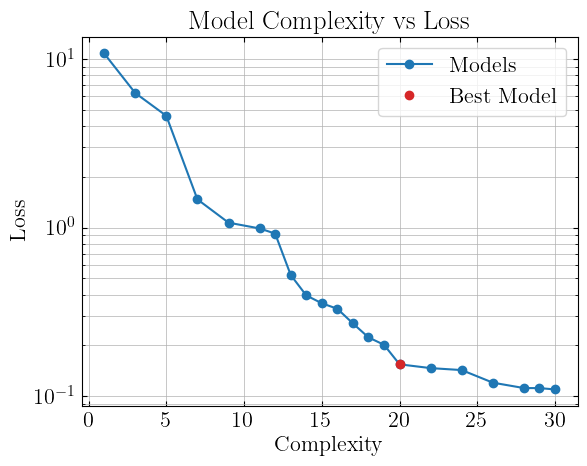

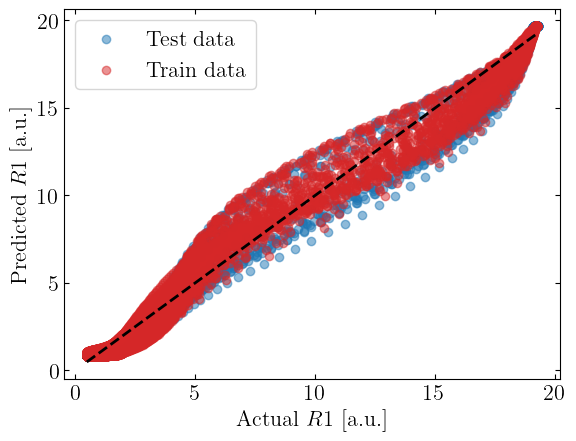

In [35]:
import_reload()
model_R1 = Param_symbol.run_symbolic_regression(X_train, YR1_train, model = None,run_id = f'R1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_R1 = model_R1.equations_
Param_symbol.print_models(df_model_R1)
Param_symbol.print_best_model(model_R1)
Param_symbol.pareto_plot(model_R1)
Param_symbol.parity_plot('R1',model_R1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $C_1 = f_C(i,u,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=21.86521
Equation: 6.8604555

Model 1: Complexity=3, Loss=20.79475
Equation: 7.397986 - x2

Model 2: Complexity=5, Loss=17.34003
Equation: (1.4027767 - x2) * 7.9262433

Model 3: Complexity=7, Loss=6.6092496
Equation: (x2 * (0.91867006 - x2)) * 51.42067

Model 4: Complexity=9, Loss=2.6117961
Equation: square(x2 * (-18.644352 * (0.8802375 - x2)))

Model 5: Complexity=10, Loss=1.7815741
Equation: exp((0.8387817 - x2) * (x2 * 14.939253))

Model 6: Complexity=11, Loss=1.190172
Equation: cube(x2 * cube(2.439493 - (x2 * 1.5631156)))

Model 7: Complexity=13, Loss=1.1042933
Equation: cube((1.153017 - (x2 * (2.0675075 - x2))) * (12.318168 * x2))

Model 8: Complexity=15, Loss=1.0991979
Equation: cube(((x2 * (1.1371124 - (x2 * (2.0467663 - x2)))) * 12.990795) + -0.08650945)

Model 9: Complexity=17, Loss=0.9592433
Equation: cube((1.1538432 - (x2 * (2.068758 - x2))) * (x2 * ((x1 * 0.019059582) - -12.083732)))

Model 10: Complexity=19, Loss=0.71674687
Equation: cube(((1.12

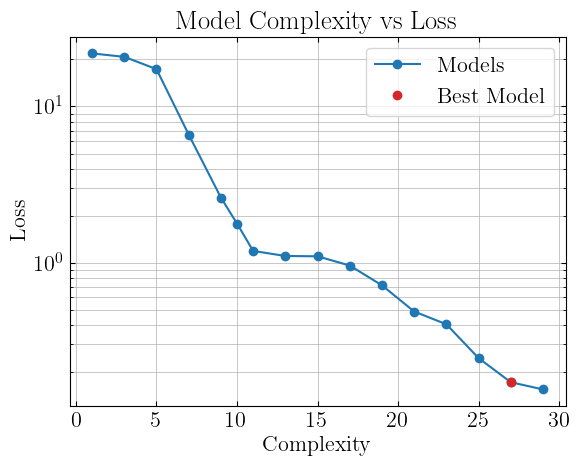

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: ((1.0547504 - x2*(2.0051253 - x2))*(-0.33295497*x0 + x2*(-(-0.029940858)*x1 + 14.570666 - 2.0157163/x0)) + 0.44606006)**3
Loss: 0.17182755
Best model complexity: 27


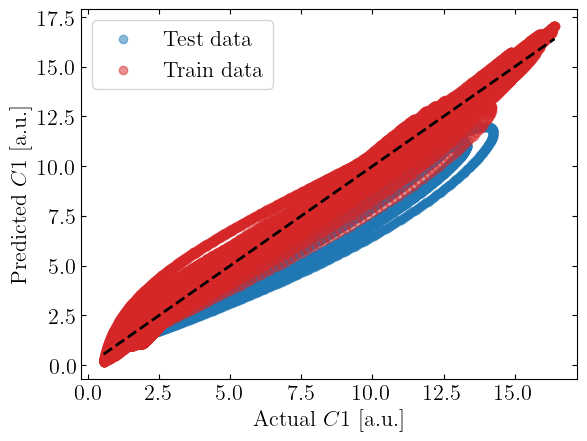

In [36]:
import_reload()
model_C1 = Param_symbol.run_symbolic_regression(X_train, YC_train, model = None,run_id = f'C1_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_C1 = model_C1.equations_
Param_symbol.print_models(df_model_C1)
Param_symbol.pareto_plot(model_C1)
Param_symbol.print_best_model(model_C1)
Param_symbol.parity_plot('C1', model_C1, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $k = f_k(i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.13329796
Equation: 2.6882355

Model 1: Complexity=5, Loss=0.0010376873
Equation: -201.84697 / (x1 + -88.12248)

Model 2: Complexity=7, Loss=0.00051489164
Equation: -201.50313 / ((x1 - x2) + -87.46041)

Model 3: Complexity=9, Loss=9.022359e-05
Equation: -201.84453 / ((x1 - (x2 * 3.027158)) + -86.5038)

Model 4: Complexity=11, Loss=4.6851907e-05
Equation: (((x2 / 0.12955876) + -168.9158) / (x1 + -81.26564)) - -0.2683445

Model 5: Complexity=13, Loss=8.896825e-06
Equation: (((x1 * 0.0023357728) + 0.08583683) * ((x1 / 3.8717573) - x2)) + 2.3495123

Model 6: Complexity=15, Loss=8.769036e-06
Equation: (((x1 / 4.1432014) + (0.8172663 - x2)) * ((x1 * 0.0024941482) - -0.083898656)) + 2.279822

Model 7: Complexity=17, Loss=7.4917834e-06
Equation: ((((x1 + sqrt(x1)) * 0.002077422) - -0.08254895) * ((x1 / 3.8817801) - x2)) + 2.348482

Model 8: Complexity=19, Loss=5.013397e-06
Equation: (((sqrt(x1) * ((x1 * 0.00019929101) + 0.0082485415)) - -0.07876196) * ((x1 / 3.8790

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (0.253460014338233*x1 - x2)*(0.012872876*sqrt(x1 - x2**3 + exp(0.10051324*x1 + 0.10051324*x2)) + 0.068156585) + 2.346695
Loss: 1.9478487e-06
Best model complexity: 28


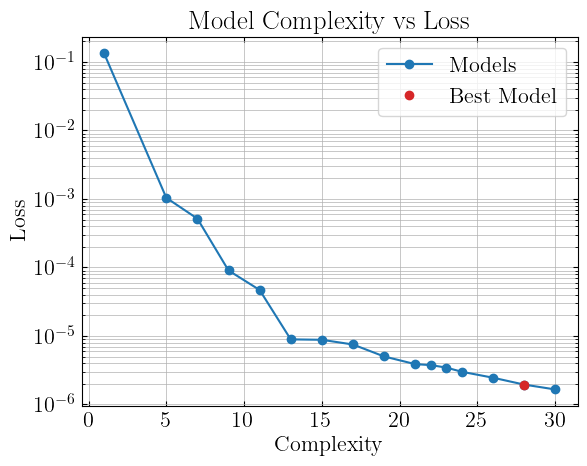

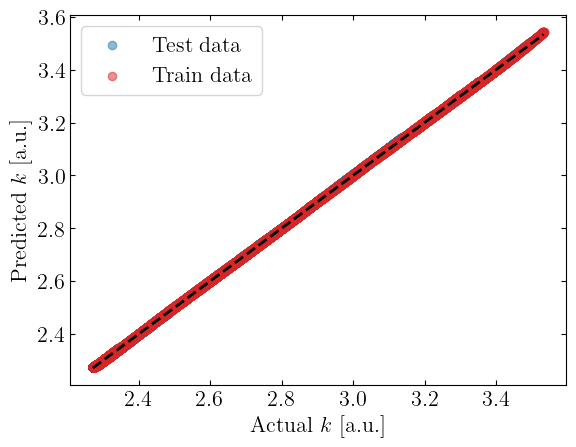

In [37]:
import_reload()
model_k = Param_symbol.run_symbolic_regression(X_train, Yk_train, model = None,run_id = f'k_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_k = model_k.equations_
Param_symbol.print_models(df_model_k)
Param_symbol.print_best_model(model_k)
Param_symbol.pareto_plot(model_k)
Param_symbol.parity_plot('k',model_k, X_test = X_test,Y_test = Y_test_dict,X_train = X_train,Y_train = Y_train_dict, data_set = 'both')

# $\dot s = f_s(s,i,d,\mathrm{SOC})$

/Users/jonatanharaldsson/Library/CloudStorage/OneDrive-Personal/0_Skola/Thesis/MSc_thesis/program/.venv/lib/python3.12/site-packages/pysr/sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(


Model 0: Complexity=1, Loss=0.009704461
Equation: 0.1660344

Model 1: Complexity=3, Loss=0.00012289156
Equation: x0 * 0.099672616

Model 2: Complexity=5, Loss=0.00012288877
Equation: 0.00010752671 - (x0 * -0.09962366)

Model 3: Complexity=7, Loss=2.5439302e-05
Equation: ((x1 * -0.0005105857) - -0.10581388) * x0

Model 4: Complexity=9, Loss=1.0289605e-05
Equation: x0 * (((x1 * -0.0007961319) * x2) - -0.105062924)

Model 5: Complexity=11, Loss=5.4353545e-06
Equation: (((x1 * -0.00050981104) + (x2 * -0.009074272)) - -0.110902876) * x0

Model 6: Complexity=13, Loss=3.1408892e-06
Equation: x0 * (((x1 + 17.347813) * (-0.00033482345 - (x2 * 0.00030992346))) - -0.11462649)

Model 7: Complexity=15, Loss=1.599825e-06
Equation: ((sqrt(x1 + 3.4377973) * ((x3 * 7.0483666e-6) + -0.00471769)) - -0.11313797) * x0

Model 8: Complexity=17, Loss=1.3066157e-06
Equation: ((((x2 * -0.002380944) + -0.0027203732) * sqrt(x1 + 4.9069)) - -0.11606736) * (x0 + -0.011375533)

Model 9: Complexity=19, Loss=1.1775071

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Best model in symbolic form: (x0 - 0.011375533)*(sqrt(x1 + 4.9069)*(-0.002380944*x2 - 0.0027203732) + 0.11606736)
Loss: 1.3066157e-06
Best model complexity: 17


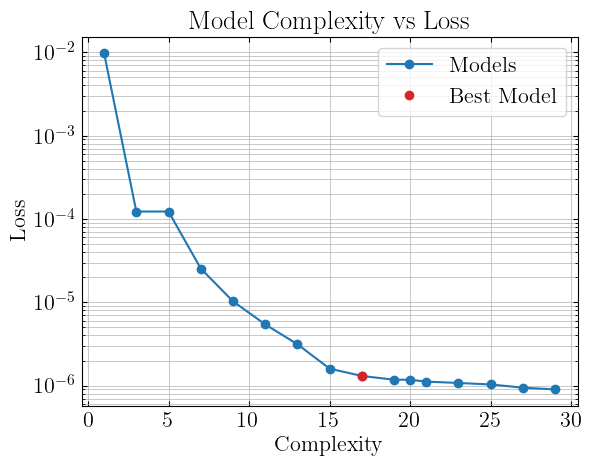

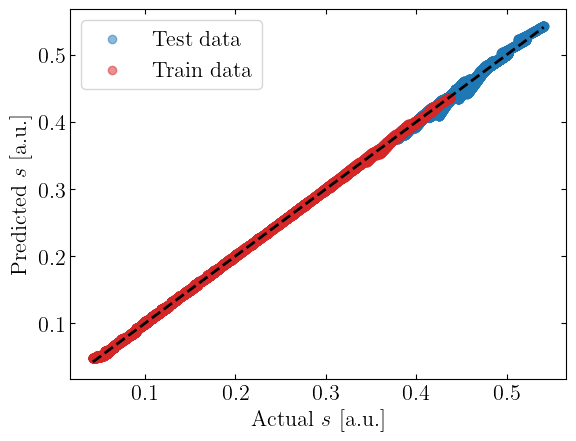

In [38]:
import_reload()
model_s = Param_symbol.run_symbolic_regression(Xs_train, Ys_train, model = None,run_id = f's_{RUN_ID}', its = ITS, selection = SELECTION)
df_model_s = model_s.equations_
Param_symbol.print_models(df_model_s)
Param_symbol.print_best_model(model_s, s = True)
Param_symbol.pareto_plot(model_s)
Param_symbol.parity_plot('s',model_s, X_test = Xs_test,Y_test = Y_test_dict,X_train = Xs_train,Y_train = Y_train_dict, data_set = 'both')

In [39]:
MODEL_DICT = {
    'R0': model_R0,
    'R1': model_R1,
    'C1': model_C1,
    'k':  model_k,
    's':  model_s
}

In [40]:
def get_traj(trajectory_id, test = False):
    if test:
        traj = data_test[data_test['trajectory'] == trajectory_id + split_train]
    else:
        traj = data_train[data_train['trajectory'] == trajectory_id]
    return traj

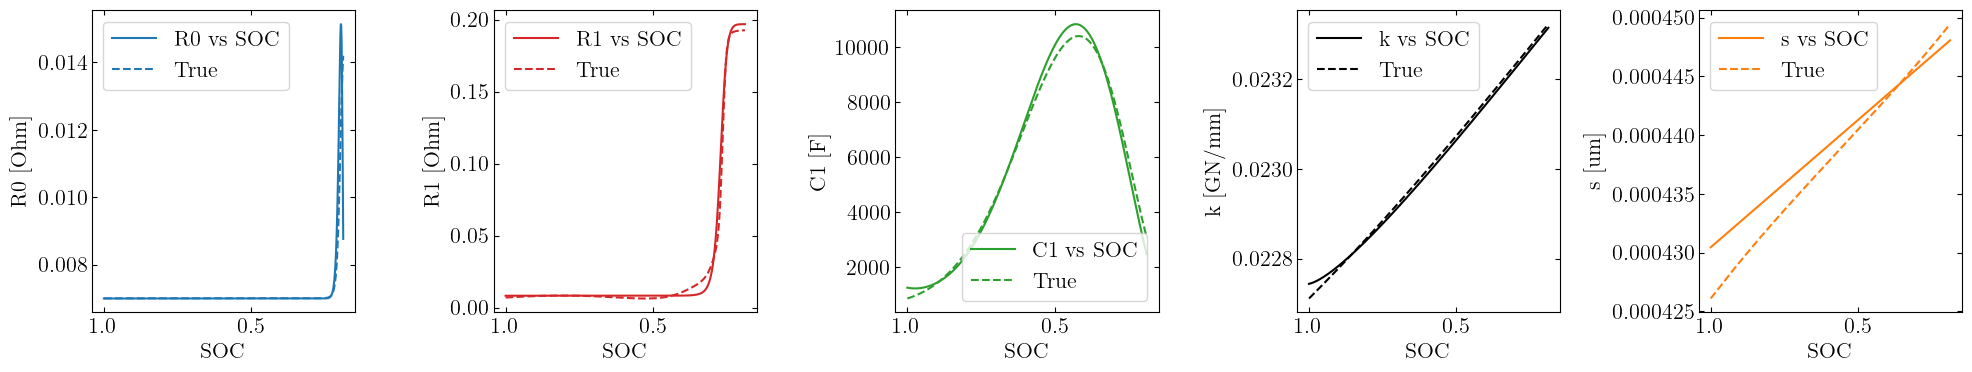

In [41]:
def plot_soc(models, traj):
    C_fixed = traj['C']
    u_per_fixed = traj['u_per']
    soc = traj['soc'].values

    f, ax = plt.subplots(1, N_VAR, figsize=(4*N_VAR, N_VAR*4/5))

    for var in VARIABLES:
        model = models[var]
        if var == 's':
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc, np.full_like(soc, REF_VALUES['s'])))
            Y_true = traj['sdot']
        else:
            X_plot = np.column_stack((np.full_like(soc, C_fixed), np.full_like(soc, u_per_fixed), soc))
            Y_true = traj[var]
        Y_plot = model.predict(X_plot) * REF_VALUES[var]
        ax[VARIABLES.index(var)].plot(soc, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs SOC')
        ax[VARIABLES.index(var)].set_xlabel('SOC')
        ax[VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
        ax[VARIABLES.index(var)].plot(soc, Y_true, color=COLORS[VARIABLES.index(var)], linestyle='--', label='True')
        ax[VARIABLES.index(var)].legend()
        ax[VARIABLES.index(var)].invert_xaxis()
    plt.tight_layout()



traj = get_traj(trajectory_id = 1, test = True)
plot_soc(MODEL_DICT, traj)

In [42]:
# def plot_d(models):
#     u_per = np.linspace(0,30,1000)
#     C_fixed = 1
#     C = np.linspace(0.5,5,1000)
#     u_fixed = 0
#     soc_fixed = 0.5
#     X_plot1 = np.column_stack((np.full_like(u_per, C_fixed), u_per, np.full_like(u_per, soc_fixed)))
#     X_plot2 = np.column_stack((C, np.full_like(C, u_fixed), np.full_like(C, soc_fixed)))
#     f, ax = plt.subplots(2, N_VAR, figsize=(4*N_VAR, N_VAR*8/5))

        
#     for var in VARIABLES:
#         model = models[var]
#         Y_plot = model.predict(X_plot1) * REF_VALUES[var]
#         ax[0,VARIABLES.index(var)].plot(u_per, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[0,VARIABLES.index(var)].set_xlabel(r'$\Delta u / L_{tot}$')
#         ax[0,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[0,VARIABLES.index(var)].legend()
#         Y_plot = model.predict(X_plot2) * REF_VALUES[var]
#         ax[1,VARIABLES.index(var)].plot(C, Y_plot, color=COLORS[VARIABLES.index(var)], label=f'{var} vs u_per')
#         ax[1,VARIABLES.index(var)].set_xlabel(r'C-rate')
#         ax[1,VARIABLES.index(var)].set_ylabel(f'{var} [{UNITS[var]}]')
#         ax[1,VARIABLES.index(var)].legend()
        
#     plt.tight_layout()

# plot_d(MODEL_DICT)


In [43]:
if SAVE:
    Param_symbol.save_expressions(df_model_R0, f'R0_{RUN_ID}')
    Param_symbol.save_expressions(model_R0.get_best(), f'R0_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_s, f's_{RUN_ID}')
    Param_symbol.save_expressions(model_s.get_best(), f's_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_k,  f'k_{RUN_ID}')
    Param_symbol.save_expressions(model_k.get_best(), f'k_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_R1, f'R1_{RUN_ID}')
    Param_symbol.save_expressions(model_R1.get_best(), f'R1_best_{RUN_ID}')
    Param_symbol.save_expressions(df_model_C1, f'C1_{RUN_ID}')
    Param_symbol.save_expressions(model_C1.get_best(), f'C1_best_{RUN_ID}')